# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## Общая информация

Дата выдачи: 08.12.2025

Мягкий дедлайн: 19.12.2025 23:59 MSK

Жёсткий дедлайн: 22.12.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb
* Модуль boosting.py

Username — ваша фамилия на латинице

Оценка: 10.5

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, поэтому придется научиться им пользоваться

In [1]:
from warnings import filterwarnings

import numpy as np, random
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 1337
np.random.seed(SEED)
random.seed(SEED)

sns.set(style='darkgrid')
filterwarnings('ignore')

Мы будем работать с датасетом по предсказанию гендера. Никакие фичи мы придумывать не будем, но если вам интересно, в датасете имеется:

- region — регион, в котором проводили опрос
- age — возраст опрошенного
- year — год опроса
- race — этническая принадлежность
- sch — количество классов образования
- empstat — статус трудоустройства
- occ — код профессии
- ind — код индустрии, в которой человек работает
- annhrs — число часов работы в год
- hrwage — почасовая оплата
- icwage — суммарная оплата в год
- occupation — должность

Целевая метрика ROC-AUC, потому что мы непритязательны и это не фокус этой домашки



In [2]:
df = pd.read_parquet("boosting_dataset.pq")

X = df.drop("sex", axis=1)

y = df["sex"]

In [3]:
df

,region,age,year,sex,race,sch,empstat,occ,ind,annhrs,hrwage,incwage,occupation
0,31,48,1981,1,1,12.0,12,634,628,240,4.233333,1016.0,transport
1,31,27,1981,1,2,9.0,10,901,777,1365,2.197802,3000.0,building
2,21,32,1981,1,1,16.0,10,343,859,1976,5.364372,10600.0,officeadmin
3,11,45,1981,1,1,12.0,10,75,839,2080,6.009615,12500.0,healthcare
4,11,31,1981,1,1,12.0,10,692,208,2080,6.206731,12910.0,production
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,22,37,2013,1,1,14.0,10,3255,7580,2340,38.461540,90000.0,healthcare
9996,21,30,2013,-1,1,13.0,10,9600,7470,2340,5.982906,14000.0,transport
9997,31,38,2013,-1,1,14.0,10,2630,6380,2600,7.692307,20000.0,artist
9998,21,32,2013,1,1,12.0,10,4110,8590,1200,8.333333,10000.0,foodcare


Пока что мы временно выкинем колонку с должностью, но мы к ней обязательно вернемся

Разделим на обучающую, валидационную и тестовую выборки (оставьте `random_state=1337` для воспроизводимости).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X.drop("occupation", axis=1).values, y.values, test_size=0.2, random_state=1337
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=1337
)

X_train.shape, X_valid.shape, X_test.shape

((8000, 11), (1000, 11), (1000, 11))

---

## Задание 1. Базовый градиентный бустинг (4 балла)

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='#b962c4'>**вопросы**</font> должен быть <font color='#b962c4'>**ответ**</font>. В заданиях, где нужно делать параметры, часто есть референсы из других библиотек. На случай, если объяснение из ноутбука непонятно, советуем обратиться к соответствующей документации и пощупать, как это делается там

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Существующие параметры:
- `base_model_class` — класс базовой модели нашего бустинга
- `base_model_params` — словарь с гиперпараметрами для базовой модели
- `n_estimators` — какое количество базовых моделей нужно обучить
- `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$
- `random_state`— в роли рандом стейта
- `verbose` — для тех, кому не нравится загадочность, можно включить и увидеть, сколько еще ждать конца обучения

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

1. Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`).
2. После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах).
3. После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

#### `partial_fit`

В `partial_fit` передаются данные `X: np.ndarray, y: np.ndarray` для одного шага бустинга: обучаем следующую базовую модель на антиградиенте и обновляем ансамбль.

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

In [5]:
%load_ext autoreload

In [6]:
%autoreload 2

from boosting import Boosting

### Проверка кода

In [7]:
boosting = Boosting(
    verbose=True,
    random_state=69, # не забывайте фиксировать, пожалуйста
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

  0%|          | 0/20 [00:00<?, ?it/s]

Train ROC-AUC 1.0000
Valid ROC-AUC 0.7202
Test ROC-AUC 0.7514


Хорошим знаком будет ROC-AUC в районе 0.7, в зависимости от сида. Дефолтные параметры специально такие, чтобы прогнать модель быстро, поэтому не отчаивайтесь

качество соответствует ожидаемому

---

## Задание 2. Имплементация гиперпараметров (3.5 балла | 3 бонус)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации.

В этом пункте мы будем делать кучу самых разных гиперпараметров, каждый из них прекрасен по-своему, но полноценно их эффект получится ощутить лишь на этапе их перебора (кроме, пожалуй, `rsm`), поэтому делать третью часть до второй не рекомендуется

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону. Для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**гарантии, что дефолтные параметры подойдут, нет**</font>. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотреть именно на них

### 2.1. Борьба с переобучением (1 балл)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете в дальнейшем делать для трейна, нужно будет повторить на валидации

Добавьте в вашу модель:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из `model.history`
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из `model.history`

И конкретно в метод `model.fit`:
- `eval_set: Tuple[np.ndarray] | None = None` — валидационная выборка `X_valid: np.ndarray, y_valid: np.ndarray`, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус `early_stopping_rounds`, т.е самой лучшей, после которой качество только падает

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td colspan="3" align="center"><code>early_stopping_rounds</code>, <code>eval_set</code></td>
</tr>
</table>

</div>

Продемонстрируйте, что все работает

  0%|          | 0/200 [00:00<?, ?it/s]

Early stopping at iteration 21


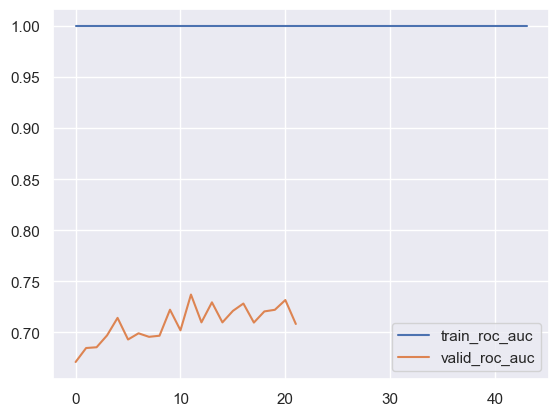

Train: 1.0
Valid: 0.7370689482757931
Test : 0.7503680942321234


In [8]:
boosting = Boosting(
    n_estimators=200,
    learning_rate=0.05,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    random_state=SEED,
    verbose=True,
)

boosting.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

boosting.plot_history(["train_roc_auc", "valid_roc_auc"])

print("Train:", boosting.score(X_train, y_train))
print("Valid:", boosting.score(X_valid, y_valid))
print("Test :", boosting.score(X_test, y_test))

обучение остановилось после 21й итерации, то есть было построено 21 дерево, после чего рок-аук стало ухудшаться. так же, на графике видно, что максимум рок-аук на валидации был примерно на 11й итерации. то есть при дальнейшем усложнении модели будет переобучение.

на обучающей выборке рок-аук 1.0 => переобучение, что логично для градиентного бустинга над деревьями, сильная подгонка под данные. 

поэтому тут необходимо было использование early_stopping, чтобы ограничивать сложность моделей, улучшать их обобщающие способности.

чуть поиграемся с параметрами. уменьшим шаг обучения до 0.01, сделаем early_stopping_rounds побольше чтобы проверить, не остановились ли мы слишком рано, может быть дальше тоже есть рост качества

  0%|          | 0/200 [00:00<?, ?it/s]

Early stopping at iteration 103


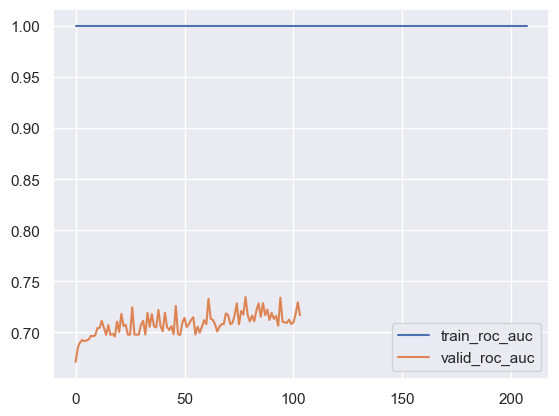

Train: 1.0
Valid: 0.734622938491754
Test : 0.7611368510338646


In [9]:
boosting = Boosting(
    n_estimators=200,
    learning_rate=0.01,
    early_stopping_rounds=25,
    eval_metric="valid_roc_auc",
    random_state=SEED,
    verbose=True,
)

boosting.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

boosting.plot_history(["train_roc_auc", "valid_roc_auc"])

print("Train:", boosting.score(X_train, y_train))
print("Valid:", boosting.score(X_valid, y_valid))
print("Test :", boosting.score(X_test, y_test))

на тесте рок-аук чуть увеличилось, и правда, становится чуть лучше. 

посмотрим а если убрать early_stopping_rounds вообще:

  0%|          | 0/500 [00:00<?, ?it/s]

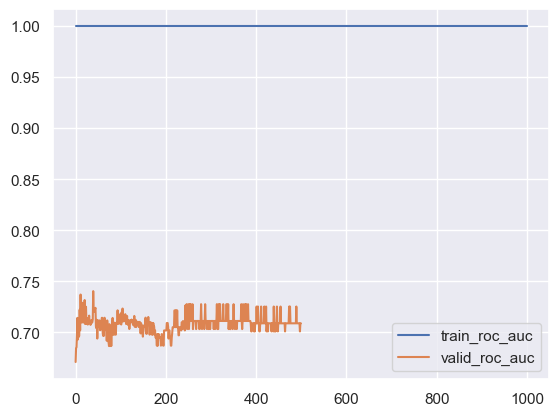

Train: 1.0
Valid: 0.7404149616598467
Test : 0.7674064560527495


In [10]:
boosting = Boosting(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=None,
    eval_metric="valid_roc_auc",
    random_state=SEED,
    verbose=True,
)

boosting.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

boosting.plot_history(["train_roc_auc", "valid_roc_auc"])

print("Train:", boosting.score(X_train, y_train))
print("Valid:", boosting.score(X_valid, y_valid))
print("Test :", boosting.score(X_test, y_test))

качество больше не растет, проверка избыточна но пусть будет

In [11]:
import time
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

### Бонус. Бустинг линейных моделей (0.5 балла)

<font color='#b962c4'>**Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?</font>

<font color='#b962c4'>**Ответ:** при ансамбле лин моделей, получится тоже линейная модель. а линейные модели слабые- так что и такой ансамбль будет слабым, и смысла в этом не много. в некоторых других задачах асамблирование может помоьч</font>




Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='#2f82d4'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="gblinear")</code></td>
<td align="center">-</td>
<td align="center">-</td>
</tr>
</table>

</div>

In [12]:
y_tr = (y_train == 1).astype(int)
y_va = (y_valid == 1).astype(int)
y_te = (y_test  == 1).astype(int)

model = xgb.XGBClassifier(
    booster="gblinear",
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()

model.fit(
    X_train, y_tr,
    eval_set=[(X_valid, y_va)],
    early_stopping_rounds=50,
    verbose=False
)

t_xgb = time.time() - t0
history = model.evals_result()["validation_0"]["logloss"]
auc_xgb = roc_auc_score(y_te, model.predict_proba(X_test)[:, 1])

Теперь возьмите `sklearn.linear_model.SGDClassifier` и обучите на тех же данных. Не забудьте понять, как вытащить оттуда историю функции потерь

In [13]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

epochs = 200
loss_tr, loss_va = [], []
classes = np.array([0, 1])

t0 = time.time()

for _ in range(epochs):
    sgd.partial_fit(X_train, y_tr, classes=classes)
    
    loss_tr.append(
        log_loss(y_tr, sgd.predict_proba(X_train))
    )
    loss_va.append(
        log_loss(y_va, sgd.predict_proba(X_valid))
    )

t_sgd = time.time() - t0

auc_sgd = roc_auc_score(y_te, sgd.predict_proba(X_test)[:, 1])

Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

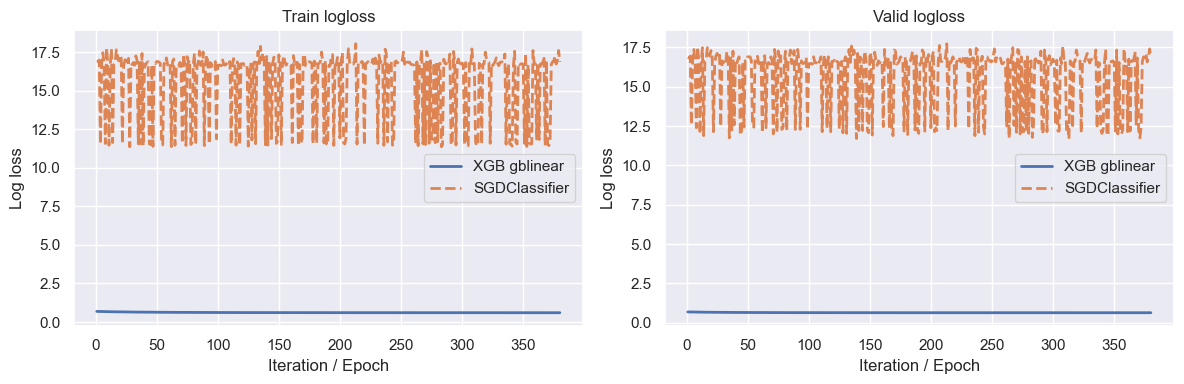

Время обучения XGBoost (gblinear): 0.09692 сек
Время обучения SGDClassifier:      0.60862 сек
ROC-AUC XGBoost (test):            0.7400
ROC-AUC SGDClassifier (test):      0.5271


In [14]:
from sklearn.linear_model import SGDClassifier


def to01(y):
    y = np.asarray(y)
    if set(np.unique(y)) == {-1, 1}:
        return (y == 1).astype(int)
    return y.astype(int)


y_tr = to01(y_train)
y_va = to01(y_valid)
y_te = to01(y_test)


xgb_model = xgb.XGBClassifier(
    booster="gblinear",
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=600,
    learning_rate=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

t0 = time.perf_counter()

xgb_model.fit(
    X_train,
    y_tr,
    eval_set=[(X_train, y_tr), (X_valid, y_va)],
    verbose=False,
    early_stopping_rounds=60,
)

xgb_time = time.perf_counter() - t0

xgb_hist = xgb_model.evals_result()
xgb_train_loss = np.array(xgb_hist["validation_0"]["logloss"], dtype=float)
xgb_valid_loss = np.array(xgb_hist["validation_1"]["logloss"], dtype=float)


sgd_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
)

epochs = len(xgb_valid_loss)
classes = np.array([0, 1])

sgd_train_loss = []
sgd_valid_loss = []

t0 = time.perf_counter()

for ep in range(epochs):
    if ep == 0:
        sgd_model.partial_fit(X_train, y_tr, classes=classes)
    else:
        sgd_model.partial_fit(X_train, y_tr)

    p_tr = sgd_model.predict_proba(X_train)
    p_va = sgd_model.predict_proba(X_valid)

    sgd_train_loss.append(log_loss(y_tr, p_tr))
    sgd_valid_loss.append(log_loss(y_va, p_va))

sgd_time = time.perf_counter() - t0

sgd_train_loss = np.array(sgd_train_loss, dtype=float)
sgd_valid_loss = np.array(sgd_valid_loss, dtype=float)


steps = np.arange(1, epochs + 1)

plt.figure(figsize=(12, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(steps, xgb_train_loss, label="XGB gblinear", linewidth=2)
ax1.plot(steps, sgd_train_loss, label="SGDClassifier", linestyle="--", linewidth=2)
ax1.set_title("Train logloss")
ax1.set_xlabel("Iteration / Epoch")
ax1.set_ylabel("Log loss")
ax1.grid(True)
ax1.legend()

ax2 = plt.subplot(1, 2, 2)
ax2.plot(steps, xgb_valid_loss, label="XGB gblinear", linewidth=2)
ax2.plot(steps, sgd_valid_loss, label="SGDClassifier", linestyle="--", linewidth=2)
ax2.set_title("Valid logloss")
ax2.set_xlabel("Iteration / Epoch")
ax2.set_ylabel("Log loss")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


xgb_auc = roc_auc_score(y_te, xgb_model.predict_proba(X_test)[:, 1])
sgd_auc = roc_auc_score(y_te, sgd_model.predict_proba(X_test)[:, 1])

print(f"Время обучения XGBoost (gblinear): {xgb_time:.5f} сек")
print(f"Время обучения SGDClassifier:      {sgd_time:.5f} сек")
print(f"ROC-AUC XGBoost (test):            {xgb_auc:.4f}")
print(f"ROC-AUC SGDClassifier (test):      {sgd_auc:.4f}")

<font color='#b962c4'>**Вопрос:** Какой вывод вы можете сделать?</font>

<font color='#b962c4'>**Ответ:** 

- бустинг линейных моделей сходится быстрее, чем SGD

- так же дает заметно большее значение рок-аук

- но если вспомним про ограничения линейного ансамбля, такая модель всеравно не хороша по качеству
</font>




### 2.2. Категории 2.0 (0.75 балла)

Пока что для простоты картины мы игнорировали категориальные признаки. <font color='#c4bf0a'>CatBoost</font> в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий, который мы попробуем повторить

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$


Добавьте в модель вот это:
- `cat_features: Iterable | None` — категориальные признаки для кодирования
- `_cat_fit(self, X: np.array, y: np.ndarray)` — внутренний метод для построения счетчиков
- `_cat_transform(self, X: np.ndarray)` — внутренний метод для применения счетчиков

Лмбо сделайте энкодер отдельным классом с аналогичными методами `fit` и `transform`, это даже лучше. Его нужно прогнать всего раз для каждой из выборок

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center">-</td>
<td align="center"><code>cat_features</code></td>
</tr>
</table>

</div>

Закодируйте переменные, которые вы хотите считать категориальными, с помощью счётчиков (готовые реализации брать нельзя) и покажите эффект. Помните, что все должно быть векторизовано и красиво

In [15]:
# вернем occupation туда, где ему самое место, но это не единственная кат фича!

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, random_state=1337
)
X_test, X_valid, y_test, y_valid = train_test_split(
    X_test, y_test, test_size=0.5, random_state=1337
)

X_train.shape, X_valid.shape, X_test.shape

((8000, 12), (1000, 12), (1000, 12))

In [16]:
import numpy as np


class MeanTargetEncoder:
    def __init__(self, cat_features, alpha=10.0):
        self.cat_features = np.array(sorted(cat_features), dtype=int)
        self.alpha = float(alpha)
        self.global_mean = None
        self.tables = {}
        self.num_features = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=object)
        y = np.asarray(y).astype(float)

        self.global_mean = float(y.mean())
        self.num_features = X.shape[1]

        for j in self.cat_features:
            col = X[:, j]
            uniq, inv = np.unique(col, return_inverse=True)

            cnt = np.bincount(inv).astype(float)
            s = np.bincount(inv, weights=y).astype(float)

            enc = (s + self.alpha * self.global_mean) / (cnt + self.alpha)
            self.tables[j] = (uniq, enc)

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=object)
        n, d = X.shape

        if self.num_features is None or d != self.num_features:
            raise ValueError("Encoder was fit on a different number of features.")

        out = np.empty((n, d), dtype=float)

        all_idx = np.arange(d)
        num_idx = np.setdiff1d(all_idx, self.cat_features)

        out[:, num_idx] = X[:, num_idx].astype(float)

        for j in self.cat_features:
            uniq, enc = self.tables[j]
            col = X[:, j]

            pos = np.searchsorted(uniq, col)
            ok = (pos < len(uniq)) & (uniq[pos] == col)

            vals = np.full(n, self.global_mean, dtype=float)
            vals[ok] = enc[pos[ok]]

            out[:, j] = vals

        return out


y_train_bin = (y_train == 1).astype(int)
y_valid_bin = (y_valid == 1).astype(int)
y_test_bin  = (y_test  == 1).astype(int)

cat_cols = [0, 3, 5, 6, 7, 11]

encoder = MeanTargetEncoder(cat_features=cat_cols, alpha=10.0).fit(X_train, y_train_bin)

X_train_enc = encoder.transform(X_train)
X_valid_enc = encoder.transform(X_valid)
X_test_enc  = encoder.transform(X_test)

print(X_train_enc.shape)
print(X_train_enc[:5, 11])

model_te = Boosting(
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    verbose=True,
)

model_te.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

score_te = model_te.score(X_test_enc, y_test_bin)
print(f"ROC-AUC with target encoding: {score_te:.4f}")

(8000, 12)
[0.45628302 0.58119898 0.49065957 0.79695533 0.79695533]


  0%|          | 0/50 [00:00<?, ?it/s]

ROC-AUC with target encoding: 0.8334


Для честного сравнения

In [17]:
import numpy as np

cat_cols = np.array([0, 3, 5, 6, 7, 11])
all_cols = np.arange(X_train.shape[1])
num_cols = np.setdiff1d(all_cols, cat_cols)

X_train_num = X_train[:, num_cols].astype(float)
X_valid_num = X_valid[:, num_cols].astype(float)
X_test_num  = X_test[:,  num_cols].astype(float)


model_raw = Boosting(
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    verbose=False,
)

model_raw.fit(
    X_train_num,
    y_train_bin,
    eval_set=(X_valid_num, y_valid_bin),
    use_best_model=True,
)

score_raw = model_raw.score(X_test_num, y_test_bin)
print(f"ROC-AUC without target encoding: {score_raw:.4f}")

ROC-AUC without target encoding: 0.6933


- без Target encoding - рок аук 0.69

- а с ним- 0.83, заметное улучшение. значит категориальные признаки содержат много информации, и твой энкодер его правильно извлек.



### Бонус. Категории 3.0 (0.5 балла)

Увы, закодированные признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем утечку целевой переменной в признаки, но с этим можно жить, в частности это одна из главных фишек <font color='#c4bf0a'>CatBoost</font>, была. Почитайте [статью](https://arxiv.org/pdf/1706.09516), она интересная

Реализуйте подсчет счетчиков так, чтобы кодировка категории была только по объектам. расположенным выше в датасете (например, если у нас выборка отсортирована по времени)

Методы добавлять не нужно, разве что очень хочется, предполагается, что это дефолтное поведение бустинга, на самом деле, если не нужен `OneHotEncoder `

In [18]:
def split_numeric_and_categorical(X, cat_features):
    X = np.asarray(X, dtype=object)
    cat_features = np.array(sorted(cat_features), dtype=int)

    all_idx = np.arange(X.shape[1])
    num_features = np.setdiff1d(all_idx, cat_features)

    X_num = X[:, num_features].astype(float)
    X_cat = X[:, cat_features]

    return X_num, X_cat, num_features, cat_features

In [19]:
class OrderedMeanTargetEncoder:
    def __init__(self, cat_features, alpha=1.0):
        self.cat_features = np.array(sorted(cat_features), dtype=int)
        self.alpha = float(alpha)
        self.global_mean = None

        # Для transform
        self.tables = {}      # j -> (uniq, enc_full)
        self.num_features = None

    def fit_transform(self, X, y):
        X = np.asarray(X, dtype=object)
        y = np.asarray(y).astype(float)

        self.num_features = X.shape[1]
        self.global_mean = float(y.mean())

        X_num, X_cat, num_idx, cat_idx = split_numeric_and_categorical(X, self.cat_features)

        n = X.shape[0]
        X_cat_enc = np.empty_like(X_cat, dtype=float)

        # По каждой категориальной колонке строим ordered-encoding для train
        # и одновременно сохраняем финальные статистики (по всему train) для transform(valid/test)
        for j_local in range(X_cat.shape[1]):
            j_global = cat_idx[j_local]          # исходный индекс колонки в X
            col = X_cat[:, j_local]

            uniq, inv = np.unique(col, return_inverse=True)
            m = len(uniq)

            sum_y = np.zeros(m, dtype=float)
            cnt = np.zeros(m, dtype=float)

            enc_train = np.empty(n, dtype=float)

            for i in range(n):
                k = inv[i]
                enc_train[i] = (sum_y[k] + self.alpha * self.global_mean) / (cnt[k] + self.alpha)
                sum_y[k] += y[i]
                cnt[k] += 1

            X_cat_enc[:, j_local] = enc_train

            # финальная “неупорядоченная” кодировка по всему train — для valid/test
            enc_full = (sum_y + self.alpha * self.global_mean) / (cnt + self.alpha)
            self.tables[int(j_global)] = (uniq, enc_full)

        return np.hstack([X_num, X_cat_enc])

    def transform(self, X):
        X = np.asarray(X, dtype=object)
        n, d = X.shape

        if self.num_features is None or d != self.num_features:
            raise ValueError("Encoder was fit on a different number of features.")

        X_num, X_cat, num_idx, cat_idx = split_numeric_and_categorical(X, self.cat_features)

        X_cat_enc = np.empty_like(X_cat, dtype=float)

        # Для каждой cat-колонки маппим категорию -> enc_full, unseen -> global_mean
        for j_local in range(X_cat.shape[1]):
            j_global = int(cat_idx[j_local])
            uniq, enc_full = self.tables[j_global]
            col = X_cat[:, j_local]

            pos = np.searchsorted(uniq, col)
            ok = (pos < len(uniq)) & (uniq[pos] == col)

            vals = np.full(n, self.global_mean, dtype=float)
            vals[ok] = enc_full[pos[ok]]

            X_cat_enc[:, j_local] = vals

        return np.hstack([X_num, X_cat_enc])

применим это к данным

In [20]:
cat_cols = [0, 3, 5, 6, 7, 11]

encoder = OrderedMeanTargetEncoder(cat_features=cat_cols, alpha=10.0)

X_train_enc = encoder.fit_transform(X_train, y_train_bin)
X_valid_enc = encoder.transform(X_valid)
X_test_enc  = encoder.transform(X_test)

print(X_train_enc.shape)
print(X_train_enc[:5, -1])

(8000, 12)
[0.4915     0.4915     0.4915     0.4915     0.53772727]


ранние объекты закодированы почти одинаково, далее кодировка становится более информативной

обучим модели

In [21]:
model_ord = Boosting(
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    verbose=True,
)

model_ord.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

score_ord = model_ord.score(X_test_enc, y_test_bin)
print(f"ROC-AUC with ordered target encoding: {score_ord:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

ROC-AUC with ordered target encoding: 0.8344


сравнение

In [22]:
model_naive = Boosting(
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    verbose=False,
)

model_naive.fit(
    X_train_num,
    y_train_bin,
    eval_set=(X_valid_num, y_valid_bin),
    use_best_model=True,
)

score_raw = model_naive.score(X_test_num, y_test_bin)
print(f"ROC-AUC without categorical encoding: {score_raw:.4f}")

ROC-AUC without categorical encoding: 0.6933


- точно так же: качество заметно улучшается с использованием кодирования

### 2.3. Бутстрап (0.75 балла)
Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

> Идея, которая за этим стоит проста - бустинги переобучаются, как черти. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

Вам нужно реализовать параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float = 1.0` — температура для генерации весов. Соответствует бутстрапу типа `Bayesian`. Каждому объекту присваивается вес $w$, который получается из температуры $t$, после чего объект, в количестве $w$, попадает в выборку. \
$w = (-\log(X))^t$, где $X \sim {U[0, 1]}$ \
Таким образом можно сделать симуляцию повторений, обобщив на непрерывный случай. Обычный бутстрап не умеет сэмплировать дробное число объектов, но можно сделать примерно то же самое, если размножить объект $w$ раз, либо присвоить вес. Подумайте, как это корректно реализовать в бустинге
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>subsample</code>, -</td>
<td align="center"><code>subsample</code>, <code>bagging</code></td>
<td align="center"><code>subsample</code>, <code>bootstrap_type</code></td>
</tr>
</table>

</div>

<font color='#b962c4'>**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?</font>

<font color='#b962c4'>**Ответ:** в бустинге бутстрап снижает разброс, тк базовые модели обучаются на разных выборках. это еще и снижает переобучение.  </font>

In [23]:
import matplotlib.pyplot as plt

N_ESTIMATORS = 200
RANDOM_SEED = 42
LR = 0.1


model_bern = Boosting(
    n_estimators=N_ESTIMATORS,
    learning_rate=LR,
    bootstrap_type="Bernoulli",
    subsample=0.2,
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    random_state=RANDOM_SEED,
    eval_metric="valid_roc_auc",
    verbose=False,
)


model_bayes = Boosting(
    n_estimators=N_ESTIMATORS,
    learning_rate=LR,
    bootstrap_type="Bayesian",
    bagging_temperature=2.0,
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    random_state=RANDOM_SEED,
    eval_metric="valid_roc_auc",
    verbose=False,
)


model_bern.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

model_bayes.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

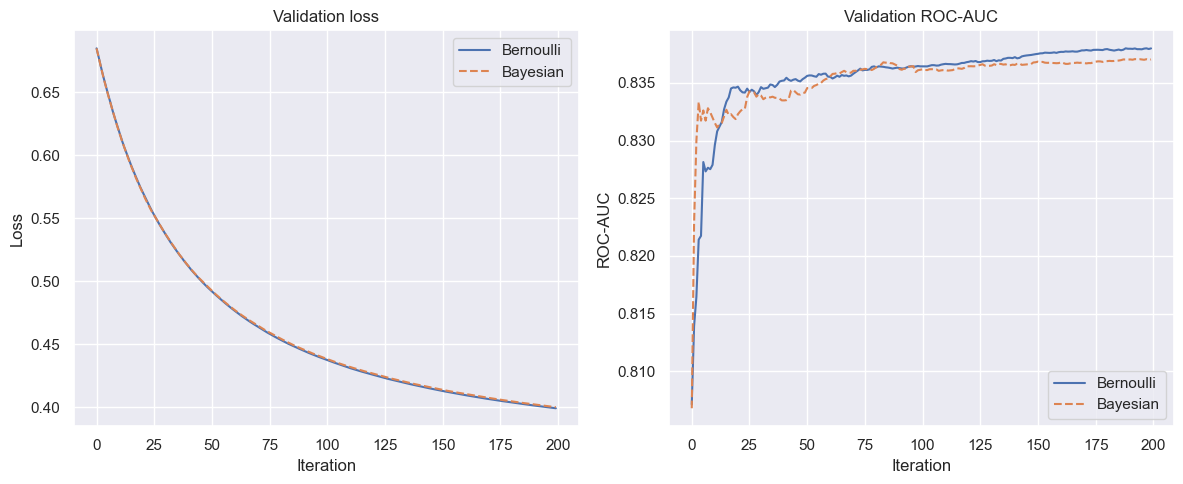

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model_bern.history["valid_loss"], label="Bernoulli")
plt.plot(model_bayes.history["valid_loss"], label="Bayesian", linestyle="--")
plt.title("Validation loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(model_bern.history["valid_roc_auc"], label="Bernoulli")
plt.plot(model_bayes.history["valid_roc_auc"], label="Bayesian", linestyle="--")
plt.title("Validation ROC-AUC")
plt.xlabel("Iteration")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [25]:
score_bern = model_bern.score(X_test_enc, y_test_bin)
score_bayes = model_bayes.score(X_test_enc, y_test_bin)

print(f"Test ROC-AUC (Bernoulli): {score_bern:.4f}")
print(f"Test ROC-AUC (Bayesian):  {score_bayes:.4f}")

Test ROC-AUC (Bernoulli): 0.8492
Test ROC-AUC (Bayesian):  0.8473


- оба варианта примерно одинаокво улучшают обобщающую способность

- Bernoulli чуть лучше по рок-аук

- стоит поиграться с паарметрами для лучшего результата

Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Нужно добавить параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

In [26]:
import matplotlib.pyplot as plt

N_ESTIMATORS = 200
RANDOM_SEED = 42
LR = 0.1


model_no_rsm = Boosting(
    n_estimators=N_ESTIMATORS,
    learning_rate=LR,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    rsm=1.0,
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    random_state=RANDOM_SEED,
    eval_metric="valid_roc_auc",
    verbose=False,
)


model_rsm = Boosting(
    n_estimators=N_ESTIMATORS,
    learning_rate=LR,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    rsm=0.5,
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    random_state=RANDOM_SEED,
    eval_metric="valid_roc_auc",
    verbose=False,
)


model_no_rsm.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

model_rsm.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

построим графики

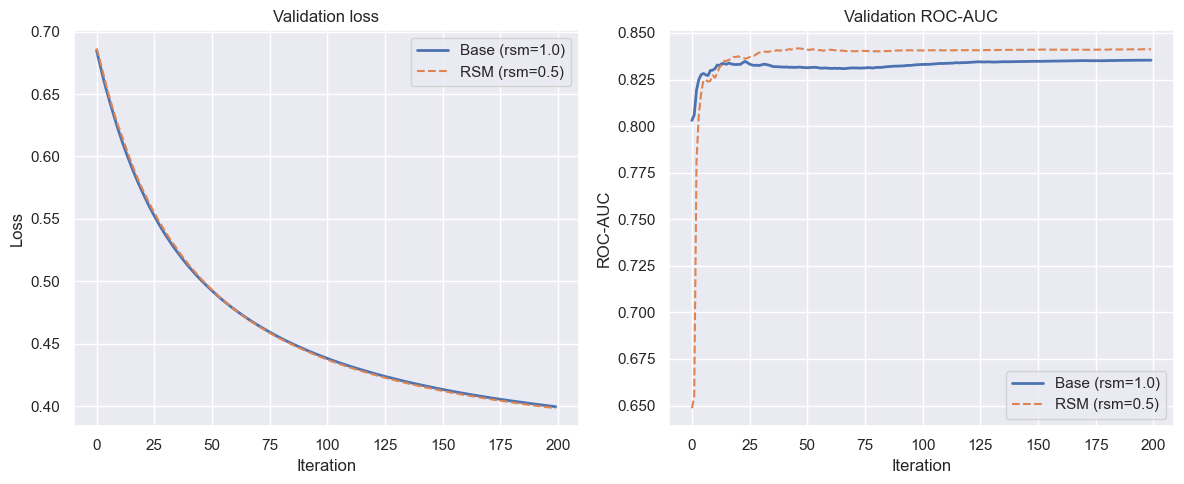

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    model_no_rsm.history["valid_loss"],
    label="Base (rsm=1.0)",
    linewidth=2,
)
plt.plot(
    model_rsm.history["valid_loss"],
    label="RSM (rsm=0.5)",
    linestyle="--",
)
plt.title("Validation loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(
    model_no_rsm.history["valid_roc_auc"],
    label="Base (rsm=1.0)",
    linewidth=2,
)
plt.plot(
    model_rsm.history["valid_roc_auc"],
    label="RSM (rsm=0.5)",
    linestyle="--",
)
plt.title("Validation ROC-AUC")
plt.xlabel("Iteration")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
score_no_rsm = model_no_rsm.score(X_test_enc, y_test_bin)
score_rsm = model_rsm.score(X_test_enc, y_test_bin)

print("Результаты")
print(f"Test ROC-AUC (Base, rsm=1.0): {score_no_rsm:.4f}")
print(f"Test ROC-AUC (RSM, rsm=0.5):  {score_rsm:.4f}")

Результаты
Test ROC-AUC (Base, rsm=1.0): 0.8448
Test ROC-AUC (RSM, rsm=0.5):  0.8447


- Использование случайного подмножества признаков действует как регуляризатор, и здесь качество почти не меняется, тк модель уже достаточно регуляризована

### Бонус. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

Параметры, которые нужно сделать:

- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center"><code>bagging='goss'</code></td>
<td align="center"><code>bootstrap_type='MVS'</code></td>
</tr>
</table>

</div>

Сделайте и посмотрите

In [29]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 2.4. Бинаризация (0.5 балла)

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет.

> Зачем это? Да все очень просто! Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее. Беда лишь в новых данных, которые могут оказаться вне бина, но великие силы избавили нас от этих проблем в нашем датасете. Фактически мотивация вновь та же, что у бутстрапа

Нужно добавить параметры:
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

Либо сделать квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>tree_method</code></td>
<td align="center"><code>max_bin</code></td>
<td align="center"><code>quantize(...)</code></td>
</tr>
</table>

</div>

Разницу между ними вы можете увидеть на картинке, где квантизуется гауссиана

<img src="https://i.postimg.cc/gJ2SJgpN/image-2025-11-29-201502496.png">

Реализуйте их, примените их к числовым признакам, и покажите, что все работает четко

In [30]:
from typing import Literal


class FeatureQuantizer:
    def __init__(
        self,
        quantization_type: Literal["uniform", "quantile"] | None = None,
        nbins: int = 255,
    ):
        self.quantization_type = quantization_type
        self.nbins = nbins
        self.bin_edges_ = {}
        self.num_idx_ = None

    def fit(self, X: np.ndarray, numerical_features_indices: list[int]):
        if self.quantization_type is None:
            return self

        X = np.asarray(X, dtype=float)
        self.num_idx_ = list(numerical_features_indices)

        for j in self.num_idx_:
            col = X[:, j]
            col = col[~np.isnan(col)]

            if col.size == 0:
                self.bin_edges_[j] = None
                continue

            if self.quantization_type == "uniform":
                edges = np.linspace(col.min(), col.max(), self.nbins + 1)[1:-1]

            elif self.quantization_type == "quantile":
                qs = np.linspace(0, 1, self.nbins + 1)[1:-1]
                edges = np.quantile(col, qs)

            self.bin_edges_[j] = np.unique(edges)

        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        if self.quantization_type is None:
            return X

        X = np.asarray(X, dtype=float)
        Xq = X.copy()

        for j in self.num_idx_:
            edges = self.bin_edges_.get(j)
            if edges is None:
                continue

            col = X[:, j]
            nan_mask = np.isnan(col)

            bins = np.digitize(col, edges, right=True)
            bins[nan_mask] = self.nbins  # отдельный бин для NaN

            Xq[:, j] = bins

        return Xq.astype(int)

In [31]:
num_idx = [i for i in range(X_train_enc.shape[1]) if i not in cat_cols]

quant_q = FeatureQuantizer("quantile", nbins=10)
quant_q.fit(X_train_enc, num_idx)

X_train_q = quant_q.transform(X_train_enc)
X_valid_q = quant_q.transform(X_valid_enc)
X_test_q  = quant_q.transform(X_test_enc)

quant_u = FeatureQuantizer("uniform", nbins=10)
quant_u.fit(X_train_enc, num_idx)

X_train_u = quant_u.transform(X_train_enc)
X_valid_u = quant_u.transform(X_valid_enc)
X_test_u  = quant_u.transform(X_test_enc)

посмотрим на уникальные значения

In [32]:
feat = num_idx[0]

print("Исходный признак")
print("unique:", len(np.unique(X_train_enc[:, feat])))

print("\nQuantile")
print("unique:", len(np.unique(X_train_q[:, feat])))
print("values:", X_train_q[:10, feat].astype(int))

print("\nUniform")
print("unique:", len(np.unique(X_train_u[:, feat])))
print("values:", X_train_u[:10, feat].astype(int))

Исходный признак
unique: 7

Quantile
unique: 7
values: [5 3 5 3 3 3 2 4 3 6]

Uniform
unique: 5
values: [9 8 9 8 8 8 5 8 8 9]


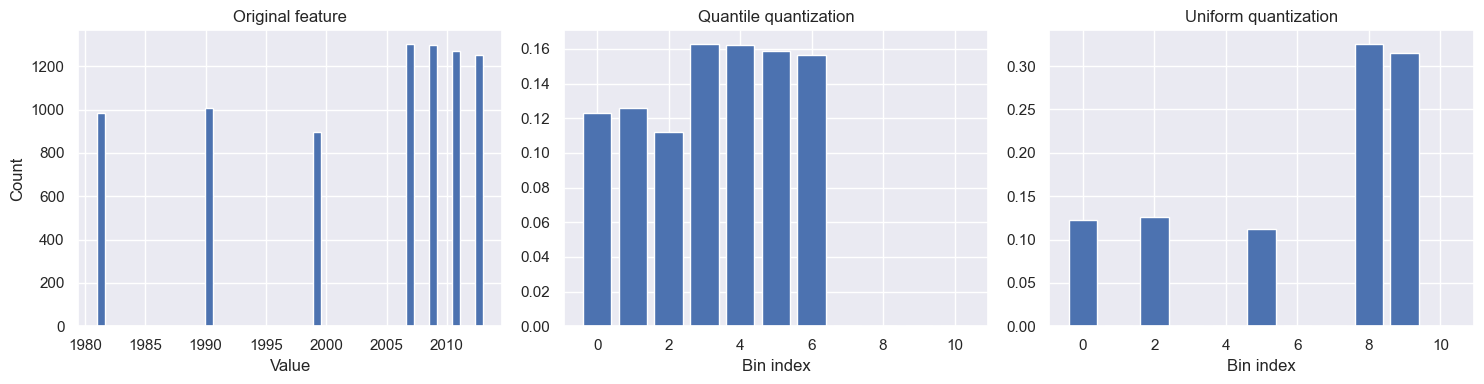

In [33]:
feature_raw = X_train_enc[:, feat]
feature_q = X_train_q[:, feat]
feature_u = X_train_u[:, feat]

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(feature_raw, bins=50)
plt.title("Original feature")
plt.xlabel("Value")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
plt.hist(
    feature_q,
    bins=np.arange(quant_q.nbins + 2) - 0.5,
    rwidth=0.8,
    density=True,
)
plt.title("Quantile quantization")
plt.xlabel("Bin index")

plt.subplot(1, 3, 3)
plt.hist(
    feature_u,
    bins=np.arange(quant_u.nbins + 2) - 0.5,
    rwidth=0.8,
    density=True,
)
plt.title("Uniform quantization")
plt.xlabel("Bin index")

plt.tight_layout()
plt.show()

In [34]:
model_q = Boosting(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric="valid_roc_auc",
    verbose=False,
)

model_q.fit(
    X_train_q,
    y_train_bin,
    eval_set=(X_valid_q, y_valid_bin),
    use_best_model=True,
)

model_u = Boosting(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric="valid_roc_auc",
    verbose=False,
)

model_u.fit(
    X_train_u,
    y_train_bin,
    eval_set=(X_valid_u, y_valid_bin),
    use_best_model=True,
)

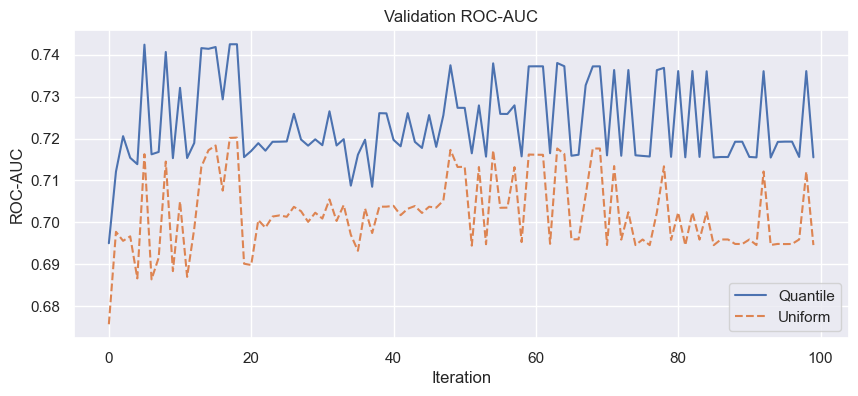

In [35]:
plt.figure(figsize=(10, 4))

plt.plot(model_q.history["valid_roc_auc"], label="Quantile")
plt.plot(model_u.history["valid_roc_auc"], label="Uniform", linestyle="--")

plt.title("Validation ROC-AUC")
plt.xlabel("Iteration")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
score_q = model_q.score(X_test_q, y_test_bin)
score_u = model_u.score(X_test_u, y_test_bin)

print(f"Test ROC-AUC (quantile): {score_q:.4f}")
print(f"Test ROC-AUC (uniform):  {score_u:.4f}")

Test ROC-AUC (quantile): 0.7310
Test ROC-AUC (uniform):  0.7330


<font color='#b962c4'>**Вопрос**: как квантизация поможет в обработке выбросов и нанов?</font>

<font color='#b962c4'>**Ответ**: квантизация снижает влияние выбросов, тк выбросы объединяются в бины с остальными значениями. наны мб выделяются в отдельный бин, и можно таким образом явно их учесть </font>

<font color='#b962c4'>**Вопрос**: можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?</font>

<font color='#b962c4'>**Ответ**: зависит от задачи. в некоторых случаях нан- это показательное и важное значение, нельзя его заполнять. также, это зависит от количества пропусков, если их много, то модель выучит искусственны зависимости. лучше делать отдельный бин для нан </font>

### Бонус. Квантизация (0.5 балла)

В современных имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, в каких-то значения повторяются, в каких-то нет, либо от того, что целевая переменная от бинов зависит опосредованно, да и пороги берутся с потолка

Есть два необычных, но крайне интересных подхода:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='#c4bf0a'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы суммарная побиновая энтропия объектов ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Это, правда, предполагает, что значения числовых фичей могут повторяться, и так и есть в части наших колонок
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета через максимизацию InfoGain \
NB: В статье делается кодирование в вектор длины $T$, где $T$ число бинов, в нашем случае это излишне, бинов можно оставить столько же, но взять лишь закодированную по формуле часть

Оба метода на самом деле похожи, поэтому выбирайте на свой вкус. Оба пытаются подобрать пороги при помощи некоторого алгоритма, который тоже работает с энтропией или InfoGain, возможно, вы его даже знаете, осталось правильно его применить. В библиотеках способы реализации чуть отличаются, и предлагаемый способ не единственный. Если есть желание - экспериментируйте!

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center">-</td>
<td align="center">-</td>
<td align="center"><code>feature_border_type="Piecewise"</code></td>
</tr>
</table>

</div>

Добавьте одну из опций, `'min_entropy'` или `'piecewise'`, для `quantization_type` и покажите, что оно работает

In [37]:
class EntropyQuantizer:
    def __init__(self, nbins: int = 16):
        self.nbins = nbins
        self.borders_ = {}
        self.num_idx_ = None

    def _entropy(self, y):
        if y.size == 0:
            return 0.0
        p = y.mean()
        if p == 0 or p == 1:
            return 0.0
        return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

    def _best_splits(self, x, y):
        base_entropy = self._entropy(y)

        candidates = []
        for i in range(1, len(x)):
            if x[i] == x[i - 1]:
                continue

            y_l = y[:i]
            y_r = y[i:]

            gain = base_entropy \
                - (len(y_l) / len(y)) * self._entropy(y_l) \
                - (len(y_r) / len(y)) * self._entropy(y_r)

            thr = 0.5 * (x[i] + x[i - 1])
            candidates.append((gain, thr))

        candidates.sort(reverse=True, key=lambda t: t[0])
        return [t[1] for t in candidates[: self.nbins - 1]]

    def fit(self, X, y, numerical_features_indices):
        X = np.asarray(X, float)
        y = np.asarray(y, int)

        self.num_idx_ = numerical_features_indices
        self.borders_ = {}

        for j in self.num_idx_:
            col = X[:, j]
            mask = ~np.isnan(col)

            xs = col[mask]
            ys = y[mask]

            if len(xs) < 2:
                self.borders_[j] = np.array([])
                continue

            order = np.argsort(xs)
            xs, ys = xs[order], ys[order]

            borders = self._best_splits(xs, ys)
            self.borders_[j] = np.sort(np.unique(borders))

        return self

    def transform(self, X):
        X = np.asarray(X, float)
        Xq = X.copy()

        for j, borders in self.borders_.items():
            if len(borders) == 0:
                continue

            col = X[:, j]
            bins = np.digitize(col, borders, right=True)
            bins[np.isnan(col)] = self.nbins
            Xq[:, j] = bins

        return Xq.astype(int)

In [38]:
num_idx = [i for i in range(X_train_enc.shape[1]) if i not in cat_cols]

quant_ent = EntropyQuantizer(nbins=10)
quant_ent.fit(X_train_enc, y_train_bin, num_idx)

X_train_ent = quant_ent.transform(X_train_enc)
X_valid_ent = quant_ent.transform(X_valid_enc)
X_test_ent  = quant_ent.transform(X_test_enc)

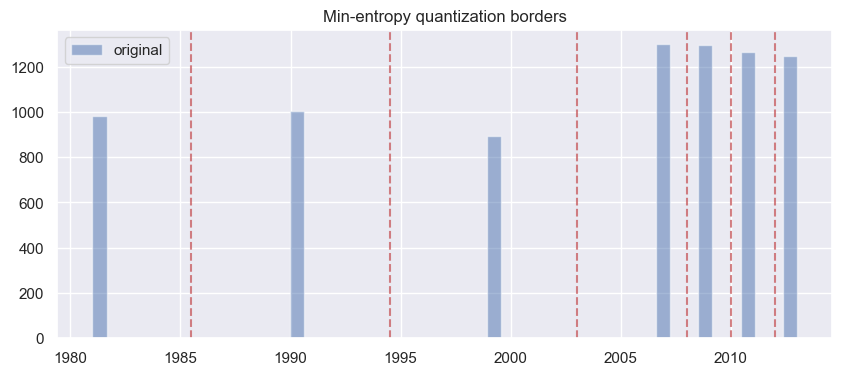

In [39]:
j = num_idx[0]

plt.figure(figsize=(10, 4))
plt.hist(X_train_enc[:, j], bins=50, alpha=0.5, label="original")
for b in quant_ent.borders_[j]:
    plt.axvline(b, color="r", linestyle="--", alpha=0.7)

plt.title("Min-entropy quantization borders")
plt.legend()
plt.show()

In [40]:
model_raw = Boosting(n_estimators=50, learning_rate=0.1, random_state=42)
model_ent = Boosting(n_estimators=50, learning_rate=0.1, random_state=42)

model_raw.fit(X_train_enc, y_train_bin)
model_ent.fit(X_train_ent, y_train_bin)

print("ROC-AUC raw:", model_raw.score(X_test_enc, y_test_bin))
print("ROC-AUC entropy:", model_ent.score(X_test_ent, y_test_bin))

ROC-AUC raw: 0.749453860188208
ROC-AUC entropy: 0.7173516420203573


рок-аук стал хуже. это может быть из-за потери информации, или, может быть, таргет уже достаточно хорошо объясняется :))

### 2.5. Важность признаков (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor` и знанием о гаммах), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так). Разумеется, способ не единственный, если хочется, посмотрите в документации

Допишите к бустингу:
- `feature_importances_` — атрибут, который возвращает важность признаков, согласно методу выше

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>model.get_score()</code></td>
<td align="center"><code>lightgbm.importance()</code></td>
<td align="center"><code>model.get_feature_importance()</code></td>
</tr>
</table>

</div>

Покажите, какие признаки оказались самыми важными

Топ-10 признаков по важности:
    feature  importance
5   empstat    0.247777
9    hrwage    0.212077
0    region    0.207555
3      race    0.114036
1       age    0.105779
10  incwage    0.049419
2      year    0.041162
8    annhrs    0.015579
4       sch    0.006617
6       occ    0.000000


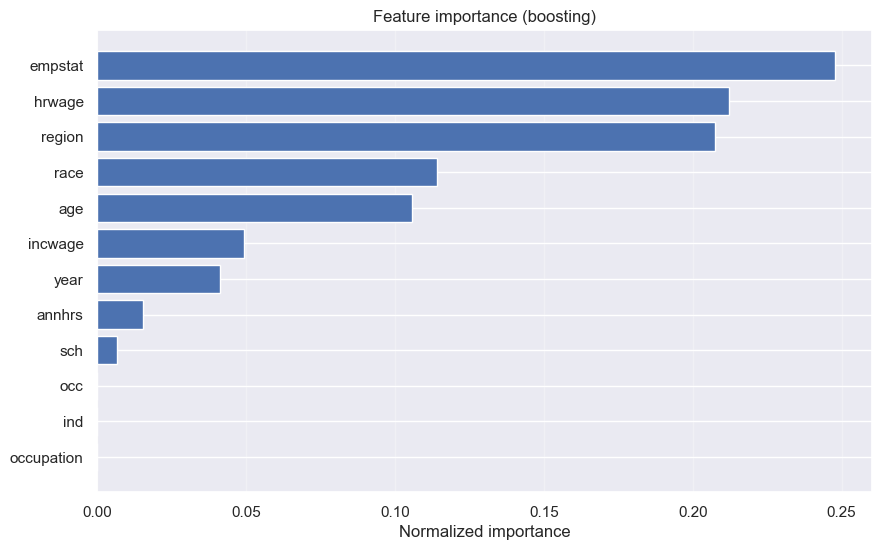

In [41]:
importances = model_ent.feature_importances_

feat_names = df.drop(columns=["sex"]).columns

imp_df = (
    pd.DataFrame({
        "feature": feat_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

print("Топ-10 признаков по важности:")
print(imp_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(
    imp_df.head(20)["feature"][::-1],
    imp_df.head(20)["importance"][::-1],
)
plt.title("Feature importance (boosting)")
plt.xlabel("Normalized importance")
plt.grid(axis="x", alpha=0.3)
plt.show()

- некоторые признаки оказались совсем не важными

### Бонус. DART (1 балл)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению, если проводить аналогию с весами. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

> В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

Параметры, которые нужно добавить:

- `dart: bool = False` — DART бустинг или нет
- `dropout_rate: float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="dart")</code></td>
<td align="center"><code>LGBMClassifier(boosting_type="dart")</code></td>
<td align="center">-</td>
</tr>
</table>

</div>

Попробуйте обучить DART на наших данных. Статью читать настоятельно рекомендуется, метод не самый простой

In [42]:
dart_model = Boosting(
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.3,
    rsm=1.0,
    dart=True,
    dropout_rate=0.1,
    base_model_params={"max_depth": 3, "min_samples_leaf": 10},
    random_state=42,
    eval_metric="valid_roc_auc",
    verbose=True,
)

dart_model.fit(
    X_train_enc,
    y_train_bin,
    eval_set=(X_valid_enc, y_valid_bin),
    use_best_model=True,
)

print(
    "Validation ROC-AUC (DART):",
    dart_model.score(X_valid_enc, y_valid_bin),
)

  0%|          | 0/100 [00:00<?, ?it/s]

Validation ROC-AUC (DART): 0.817383269533078


- хороший результат, но рок-аук все еще ниже, чем у обычного бустинга (там было 0.84)

- из-за случайного исключения дереьев теряется немного качества, но модель теперь более устойчива

------

## Задание 3. Около бустинга (2.5 балла | 0.5 бонус)

Теперь давайте проанализируем, как же правильно готовить бустинги. Нас интересует: как тюнить бустинги, какие они вообще бывают и как их интерпретировать. Посмотрим на все это по порядку

### 3.1. Optuna наносит ответный удар (0.5 балла)

Если вы помните, у нас уже было знакомство с библиотекой `optuna` для подбора гиперпараметров. Вспомним, как это делается и подумаем, как это можно делать еще лучше

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Покажите, какие из них дали наибольший прирост (для этого придется почитать документацию оптуны)

In [43]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

def objective(study, model="custom_boosting"):

    # параметры бустинга
    boosting_params = ...

    # параметры дерева
    tree_params = ...

    # параметры, зависящие от некоторого условия (e.g. subsample только для Bernoulli)
    # если не делать их условными, можно испортить процесс оптимизации
    conditional_params = ...

    pass

In [44]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 3.2. Глубокая оптимизация (1 балл)

Помимо эффективного перебора гиперпараметров, `optuna` предлагает более тонкий контроль над самой процедурой обучения

1. Посмотрите, как можно контролировать процесс обучения бустинга при помощи прунера. У библиотечных имплементаций есть уже готовые, их можно использовать пунктом ниже. Для кастомной модели возьмите что-то из [`optuna.pruners`](https://optuna.readthedocs.io/en/stable/reference/pruners.html), либо можно написать своё. Идея прунера — не обучать бустинг до конца, если по истории валидации видно, что другие бустинги на этом этапе статистически лучше, для этого мы и делали `partial_fit`.
2. Если мы ценим наше время, можно внести в процесс оптимизации немного определенности и, например, сказать, что если мы достигли определенного качества, то этого нам уже хватит с головой. Объект со смешным названием [`optuna.terminator`](https://optuna.readthedocs.io/en/stable/reference/terminator.html) позволяет нам остановить оптимизацию по достижении некоторого трешхолда по какому-либо параметру, который мы сами придумали, например, качестве на тесте

Чего от вас хочет автор?
1. Добавьте другие параметры, которые вы реализовали во время выполнения дз, в `objective`, они хорошие и могут вам помочь
1. Попробуйте ускорить оптимизацию при помощи своего или библиотечного прунера и/или терминатора. Если ускорения нет, скорее всего, вы вставили его неправильно
2. Побейте трешхолд ROC-AUC в 0.84 на тесте, если в предыдущем пункте этого сделать не удалось. Помните, что у вас есть целая история обучения, и лучшим трайалом может быть что-то из топ-10, а не только из топ-1

In [45]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 3.3. Готовые реализации (0.5 балла)

Библиотек для бустингов существует много, но активно используются лишь три. Вам предстоит попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='#2f82d4'>XGBoost</font>, <font color='#53c96c'>LightGBM</font> или <font color='#c4bf0a'>CatBoost</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, и сравнить две оптимизированные модели по
- динамике функции потерь (на обучающей и на валидационной выборке)
- времени обучения
- оптимальному набору гиперпараметров

In [46]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

<font color='#b962c4'>**Вопрос:** Какая архитектура вам нравится больше всего и почему?</font>

<font color='#b962c4'>**Ответ**: ... </font>

### Бонус. Еще пара красивых слов (0.5 балла)

Разумеется, мы рассмотрели далеко не все классные фишки, которые есть в библиотеках. Ниже есть набор заданий, выберите одно, которое кажется вам наиболее интересным

- <font color='#2f82d4'>XGBoost</font> известен тем, что в нем впервые повилась регуляризация. Ручками ее написать сложно, но тут и не требуется. Добавьте обе регуляризации, что там есть, как параметры в оптуну и прогоните процесс оптимизации только на них. Оцените экспертно, насколько прямая регуляризация эффективна, по сравнению с регуляризацией деревьев
- <font color='#53c96c'>LightGBM</font> содержит в себе в том числе реализацию своего злейшего врага - случайный лес. Посмотрите, какие есть параметры у него, обучите и ответьте на <font color='#b962c4'>вопрос "кто победит: бустинг или лес? и почему?" </font>
- <font color='#c4bf0a'>CatBoost</font> славится множеством функций, кажется в этом ноутбуке, только про них и говорили. Славится он еще и кучей разных подходов к обучению деревьев, в частности он умеет мерджить несколько моделей в одно. Это не стекинг, и даже не беггинг, а что-то поинтереснее. Попробуйте разбить выборку на фолды и обучить по катбусту на каждом из них, а затем их склеить. Тюнить их не надо, он и так неплох, в этом его сила и мудрость. Оцените, насколько это круто по 10-балльной

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>alpha</code>, <code>lambda</code></td>
<td align="center"><code>boosting_type="rf"</code></td>
<td align="center"><code>sum_models</code>, <code>to_classifier</code></td>
</tr>
</table>

</div>

Посмотрите на выбранную вами фичу и покажите, как хорошо или плохо она работает

In [47]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

### 3.4. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но таки что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

In [48]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

In [49]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

Конечно же, бустинг великолепен, как он есть, но можно сделать его еще лучше, если его откалибровать

1. Посмотрите на то, как это делать из библиотеки `sklearn`. Обратите внимание, передаете вы в него обученную модель или нет, а также на чем вы калибруетесь. Иначе есть риск что-то поломать
2. Откалибруйте вашу реализацию бустинга. Для этого за вас к нему был замешан `ClassifierMixin`
3. Покажите, как изменилась мера откалиброванности, для этого есть \
$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]$ \
$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$
4. Нарисуйте новую калибровочную кривую

In [50]:
# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

<font color='#b962c4'>**Вопрос:** Как вы можете прокомментировать то, что получилось?</font>

<font color='#b962c4'>**Ответ**: ... </font>

## Социализационный бонус. Новогоднее 🎆 (0.5 балла)

Сфотографируйтесь с наряженной новогодней или рождественской ёлкой! Приложите фотографию, опишите свои впечатления, чего вы ждете от нового 2026 года?

# *𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚*𖣂♱𖠰𖣂↟*𖠰ᨒ↟*𖥧˚

чем пользовалась при выполнении домашки:

реализация бустинга: 
- https://github.com/eriklindernoren/ML-From-Scratch/tree/master/mlfromscratch/supervised_learning
- https://github.com/eriklindernoren/ML-From-Scratch/tree/master/mlfromscratch/examples

XGB, LightGBM дока: 
- https://xgboost.readthedocs.io/en/stable/  
- https://lightgbm.readthedocs.io/en/latest/

optuna пример 
- https://github.com/optuna/optuna-examples/tree/main/sklearn